In [63]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, mean_squared_error
from sklearn.model_selection import GridSearchCV

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
# Read the CSV file in the same directory as the code
data = pd.read_csv('../data/The_Cancer_data_1500_V2.csv')
print("Dataset: ")
data.head()

Dataset: 


,Age,Gender,BMI,Smoking,GeneticRisk,PhysicalActivity,AlcoholIntake,CancerHistory,Diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040296,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [65]:
# Separate features and target
X = data.drop(columns='Diagnosis')
y = data['Diagnosis']

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
# Define the parameter grid
param_grid = {
    'max_depth': [5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 10],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

In [67]:
# Output the best parameters found
decision_tree = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=decision_tree, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters from wide grid search:", grid_search.best_params_)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best parameters from wide grid search: {'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [68]:
# Define the parameter grid that has best 2 features
param_grid_adjusted = {
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_leaf': [1, 2, 4, 6, 10],
}

In [69]:
decision_tree = DecisionTreeClassifier(random_state=42)

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator= decision_tree , param_grid=param_grid_adjusted, cv=5, n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)

best_tree = grid_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'max_depth': None, 'min_samples_leaf': 4}


In [70]:
# Extract results from the grid search
cv_results = pd.DataFrame(grid_search.cv_results_)

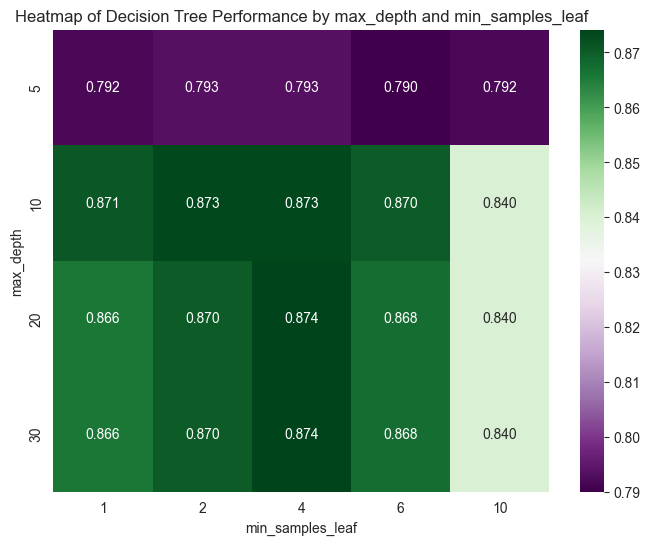

In [71]:
pivot_table = cv_results.pivot_table(values='mean_test_score',
                                     index='param_max_depth',
                                     columns='param_min_samples_leaf',)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_table, annot=True, cmap='PRGn', fmt='.3f')
plt.title("Heatmap of Decision Tree Performance by max_depth and min_samples_leaf")
plt.xlabel("min_samples_leaf")
plt.ylabel("max_depth")
plt.show()

The highest accuracy scores are observed when max_depth is set to 10, 20, or 30 and min_samples_leaf is set to 4, which leads to the highest performance. This indicates that a moderate to unrestricted level of depth control, combined with a minimum_sample_leaf set to 6 reduces overfitting by avoiding overly specific splits. In contrast, when max_depth is limited to 5, accuracy drops significantly across all values of min_samples_leaf. This lower depth appears to be too shallow for capturing the intricate patterns in the dataset, which might lead to underfitting.

In [72]:
# Train and evaluate the default DT
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
y_pred_default_tree = tree.predict(X_test)

# Calculate metrics for default DT
accuracy = accuracy_score(y_test, y_pred_default_tree)
class_report = classification_report(y_test, y_pred_default_tree)
mse_default_tree = mean_squared_error(y_test, y_pred_default_tree)  # Calculate MSE

# Calculate metrics for tuned DT
best_tree = grid_search.best_estimator_
best_tree.fit(X_train, y_train)
y_pred_best_tree = best_tree.predict(X_test)

# Calculate metrics for tuned DT
accuracy_best_tree = accuracy_score(y_test, y_pred_best_tree)
classification_report_best_tree = classification_report(y_test, y_pred_best_tree)
mse_best_tree = mean_squared_error(y_test, y_pred_best_tree)  # Calculate MSE

print("Default Decision Tree Accuracy:", accuracy)
print("Tuned Decision Tree Accuracy:", accuracy_best_tree)

print("\nDefault Decision Tree Classification Report:\n", class_report)
print("\nTuned Decision Tree Classification Report:\n", classification_report_best_tree)

print("Default Decision Tree MSE:", mse_default_tree)
print("Tuned Decision Tree MSE:", mse_best_tree)

Default Decision Tree Accuracy: 0.8766666666666667
Tuned Decision Tree Accuracy: 0.91

Default Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       184
           1       0.87      0.80      0.83       116

    accuracy                           0.88       300
   macro avg       0.87      0.86      0.87       300
weighted avg       0.88      0.88      0.88       300


Tuned Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.96      0.93       184
           1       0.93      0.83      0.88       116

    accuracy                           0.91       300
   macro avg       0.92      0.89      0.90       300
weighted avg       0.91      0.91      0.91       300

Default Decision Tree MSE: 0.12333333333333334
Tuned Decision Tree MSE: 0.09


<Figure size 1000x500 with 0 Axes>

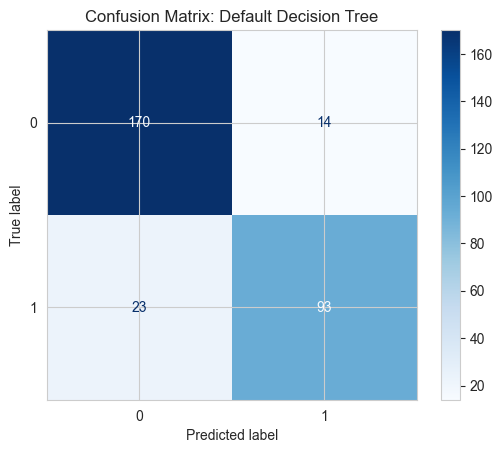

<Figure size 1000x500 with 0 Axes>

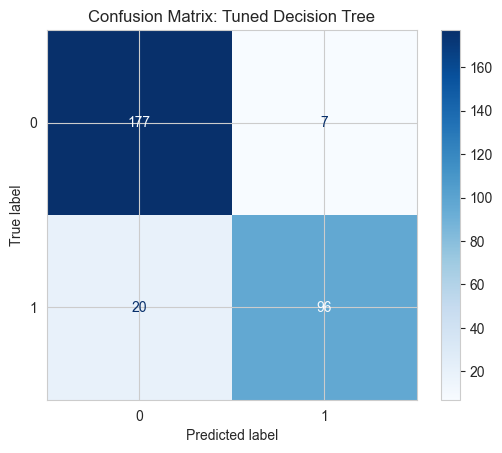

In [73]:
# Visualize confusion matrices
plt.figure(figsize=(10, 5))
ConfusionMatrixDisplay.from_estimator(tree, X_test, y_test, cmap = "Blues")
plt.title("Confusion Matrix: Default Decision Tree")
plt.show()

plt.figure(figsize=(10, 5))
ConfusionMatrixDisplay.from_estimator(best_tree, X_test, y_test, cmap = "Blues")
plt.title("Confusion Matrix: Tuned Decision Tree")
plt.show()

Background Information:

Precision is the proportion of correct positive predictions or:

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}$$

Recall is the proportion of of actual poisitives that were correctrly identified by the model:
$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives}+\text{False Positves}}$$

The tuned mode's accuracy improved slightly from 0.87 to 0.88. The F1-scores, which is a metric that balances precision and recall:
$$\text{F1 Score} = 2 \text{ x }\frac{\text{Precision x Recall}}{\text{Precision} + \text{Recall}}$$

**Default vs Tuned Decision Tree**
Based on the classification reports, confusion matrices, and Mean Squared Error (MSE) for both the default and tuned Decision Tree models, hyperparameter tuning did not significantly improve performance. The accuracy for the tuned Decision Tree models improved significantly (0.91 vs 0.87). For class 0, which represents non-cancer patients, precision and recall improved from 0.88 and 0.92 to 0.90 and 0.96, respectively. Furthermore, class 1's  precision and recall improved from 0.87 and 0.80 to 0.93 and 0.83, respectively. This suggests that the tuned model became better at identifying true negatives and reducing false positives, while also lowering false negatives and slightly improving its ability to identify true positives.

The F1-score for both classes improved with tuning, which means that both precision and recall were enhanced. Class 0’s F1 increased from 0.90 to 0.93, and class 1’s F1 increased from 0.83 to 0.88.

In terms of MSE, the tuned Decision Tree model achieved a lower MSE of 0.107 compared to the default model’s MSE of 0.123.

The confusion matrices demonstrate that hyperparameter tuning enhanced the Decision Tree model's accuracy in correctly identifying true positives, true negatives, false positives, and false negative. Specifically, it reduced the amount of false positives and slowly lowered the false negatives. This suggests an improved balance between sensitivity and specificity.

In [74]:
# Define the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [75]:
# Initialize the RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42)

# Set up GridSearchCV for Random Forest with 5-fold cross-validation
grid_search_rf = GridSearchCV(
    estimator=random_forest, 
    param_grid=param_grid_rf, 
    cv=5, 
    n_jobs=-1, 
    verbose=1,
    scoring='accuracy'
)

# Fit the grid search to the training data
grid_search_rf.fit(X_train, y_train)

# Output the best parameters found
print("Best parameters from Grid Search for Random Forest:", grid_search_rf.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters from Grid Search for Random Forest: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [76]:
# Define the best parameter grid for Random Forest
best_param_grid_rf = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

In [77]:
grid_search_rf = GridSearchCV(
    estimator=random_forest, 
    param_grid=best_param_grid_rf, 
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all available cores
    verbose=1,  # Print progress
    scoring='accuracy'  # or another metric if desired
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters found by GridSearchCV:", grid_search_rf.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found by GridSearchCV: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [78]:
default_rf = RandomForestClassifier(random_state=42)
default_rf.fit(X_train, y_train)

# Make predictions with the default model
y_pred_default_rf = default_rf.predict(X_test)

accuracy_default_rf = accuracy_score(y_test, y_pred_default_rf)
classification_report_default_rf = classification_report(y_test, y_pred_default_rf)
mse_default_rf = mean_squared_error(y_test, y_pred_default_rf)  # Calculate MSE for default RF

# Hyperparameter tuning using GridSearchCV
best_rf = grid_search_rf.best_estimator_

# Make predictions with the tuned model
y_pred_best_rf = best_rf.predict(X_test)


accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)
classification_report_best_rf = classification_report(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)  # Calculate MSE for tuned RF

# Print and display results for the default and tuned model 
print("Default Random Forest Accuracy:", accuracy_default_rf)
print("Tuned Random Forest Accuracy:", accuracy_best_rf)

print("Default Random Forest Classification Report:\n", classification_report_default_rf)
print("Tuned Random Forest Classification Report:\n", classification_report_best_rf)

print("Default Random Forest MSE:", mse_default_rf)
print("Tuned Random Forest MSE:", mse_best_rf)

Default Random Forest Accuracy: 0.93
Tuned Random Forest Accuracy: 0.9233333333333333
Default Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.96      0.94       184
           1       0.94      0.88      0.91       116

    accuracy                           0.93       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.93      0.93      0.93       300

Tuned Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.96      0.94       184
           1       0.93      0.86      0.90       116

    accuracy                           0.92       300
   macro avg       0.93      0.91      0.92       300
weighted avg       0.92      0.92      0.92       300

Default Random Forest MSE: 0.07
Tuned Random Forest MSE: 0.07666666666666666


<Figure size 800x600 with 0 Axes>

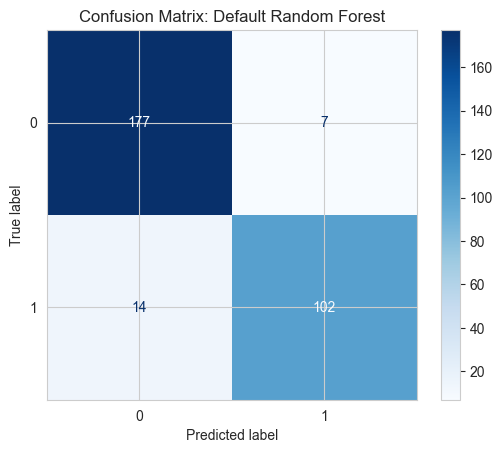

<Figure size 800x600 with 0 Axes>

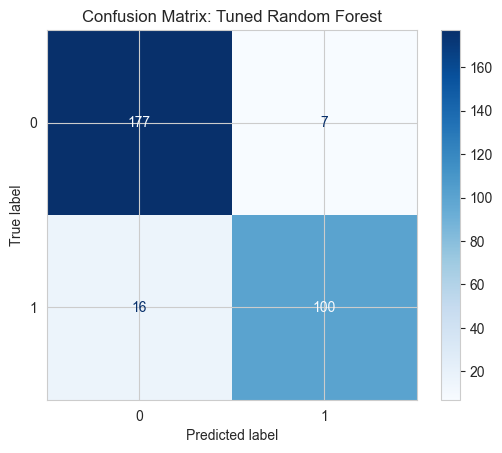

In [79]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(default_rf, X_test, y_test, cmap = "Blues")
plt.title("Confusion Matrix: Default Random Forest")

plt.show()

plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap = "Blues")
plt.title("Confusion Matrix: Tuned Random Forest")

plt.show()

**Default vs Tuned Random Forest Model**
The accuracy of the tuned Random Forest model decreased slightly (0.923 vs. 0.93), indicating that the default settings were already close to optimal. Also, the classification reports for both models show very similar precision, recall, and F1-scores across classes, and the confusion matrices are nearly identical. The MSE showed a minor change, moving from 0.07 to 0.08, further suggesting that tuning did not significantly enhance model accuracy or reduce error. Overall, hyperparameter tuning had minimal impact on the model's predictive performance.

**Gender Analysis Decision Tree and Random Forest**

In [80]:
male_data = data[data['Gender'] == 0]  # Male data
female_data = data[data['Gender'] == 1]  # Female data

In [81]:
# Define a function to evaluate both the default and tuned Decision Tree models
def evaluate_decision_tree(data, gender_label, default_model, tuned_model):
    X = data.drop(columns=['Diagnosis', 'Gender'])  # Features
    y = data['Diagnosis']  # Target variable
    
    # Split the data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train and evaluate the default Decision Tree model
    default_model.fit(X_train, y_train)
    y_pred_default = default_model.predict(X_test)
    accuracy_default = accuracy_score(y_test, y_pred_default)
    mse_default = mean_squared_error(y_test, y_pred_default)  # Calculate MSE for default model
    class_report_default = classification_report(y_test, y_pred_default)
    
    print(f"{gender_label} Default Decision Tree Accuracy:", accuracy_default)
    print(f"{gender_label} Default Decision Tree MSE:", mse_default)
    print(f"{gender_label} Default Decision Tree Classification Report:\n", class_report_default)
    
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(default_model, X_test, y_test, cmap = "Blues")
    plt.title(f"Confusion Matrix: Default Decision Tree for {gender_label}")
    plt.show()
    
    # Train and evaluate the tuned Decision Tree model
    tuned_model.fit(X_train, y_train)
    y_pred_tuned = tuned_model.predict(X_test)
    accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
    mse_tuned = mean_squared_error(y_test, y_pred_tuned)  # Calculate MSE for tuned model
    class_report_tuned = classification_report(y_test, y_pred_tuned)
    
    print(f"{gender_label} Tuned Decision Tree Accuracy:", accuracy_tuned)
    print(f"{gender_label} Tuned Decision Tree MSE:", mse_tuned)
    print(f"{gender_label} Tuned Decision Tree Classification Report:\n", class_report_tuned)
    
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(tuned_model, X_test, y_test, cmap = "Blues")
    plt.title(f"Confusion Matrix: Tuned Decision Tree for {gender_label}")
    plt.show()

Male Default Decision Tree Accuracy: 0.8888888888888888
Male Default Decision Tree MSE: 0.1111111111111111
Male Default Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.92      0.92       113
           1       0.78      0.80      0.79        40

    accuracy                           0.89       153
   macro avg       0.85      0.86      0.86       153
weighted avg       0.89      0.89      0.89       153


<Figure size 800x600 with 0 Axes>

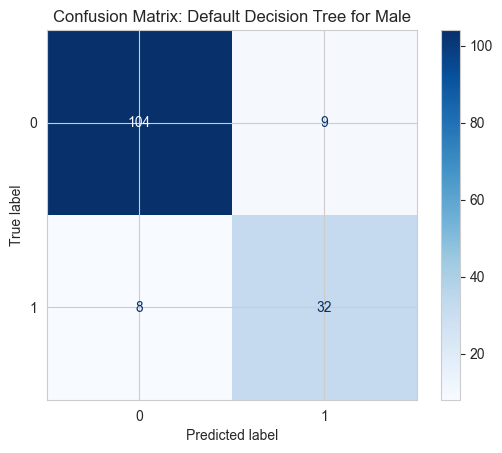

Male Tuned Decision Tree Accuracy: 0.8758169934640523
Male Tuned Decision Tree MSE: 0.12418300653594772
Male Tuned Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       113
           1       0.76      0.78      0.77        40

    accuracy                           0.88       153
   macro avg       0.84      0.84      0.84       153
weighted avg       0.88      0.88      0.88       153


<Figure size 800x600 with 0 Axes>

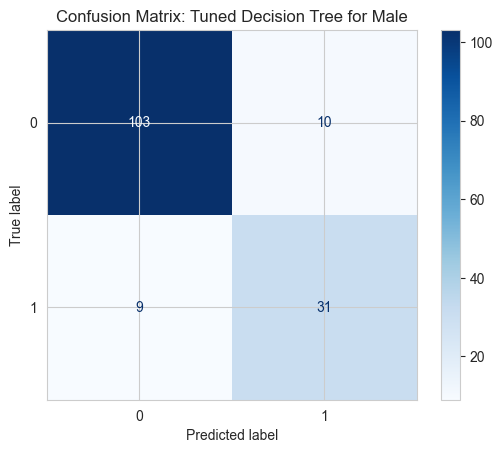

In [82]:

# Initialize the default Decision Tree model
default_tree = DecisionTreeClassifier(random_state=42)

# Use the best_tree from GridSearchCV as the tuned model
# Evaluate for Male using both default and tuned models
evaluate_decision_tree(male_data, "Male", default_model=default_tree, tuned_model=best_tree)

**Default vs. Tune Decision Tree for Male Subset**

The default Decision Tree model outperformed the tuned model in several metrics for the male subset. The default model achieved higher accuracy (0.89 vs. 0.88), precision for class 1 (cancer) (0.78 vs. 0.76), and recall for class 1 (0.80 vs. 0.70). This indicates that the default model was slightly better at identifying cancer cases without misclassifying non-cancer cases. While the tuned model improved recall for non-cancer cases (0.95 vs. 0.92), this came at the cost of lower recall for cancer cases (0.7 vs. 0).

Additionally, the Mean Squared Error (MSE) was slightly lower for the default model (0.111 vs. 0.118), reinforcing the idea that hyperparameter tuning introduced a minor trade-off. 

In summary, tuning did not yield significant improvements for the male subset and may have even slightly compromised the model’s sensitivity for identifying cancer cases. This suggests that, for this subset, the default Decision Tree configuration provided a more optimal balance of performance metrics.

Female Default Decision Tree Accuracy: 0.8378378378378378
Female Default Decision Tree MSE: 0.16216216216216217
Female Default Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.80      0.82        69
           1       0.83      0.87      0.85        79

    accuracy                           0.84       148
   macro avg       0.84      0.84      0.84       148
weighted avg       0.84      0.84      0.84       148


<Figure size 800x600 with 0 Axes>

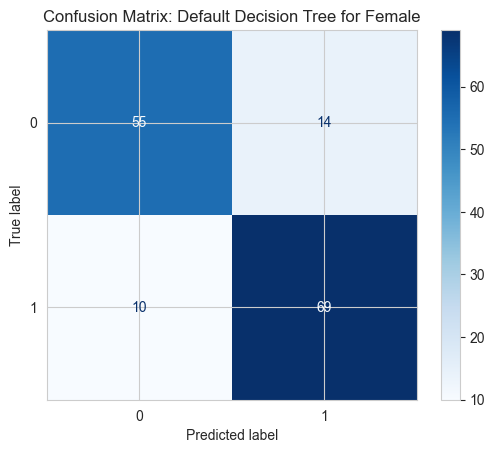

Female Tuned Decision Tree Accuracy: 0.8716216216216216
Female Tuned Decision Tree MSE: 0.12837837837837837
Female Tuned Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.88      0.87        69
           1       0.89      0.86      0.88        79

    accuracy                           0.87       148
   macro avg       0.87      0.87      0.87       148
weighted avg       0.87      0.87      0.87       148


<Figure size 800x600 with 0 Axes>

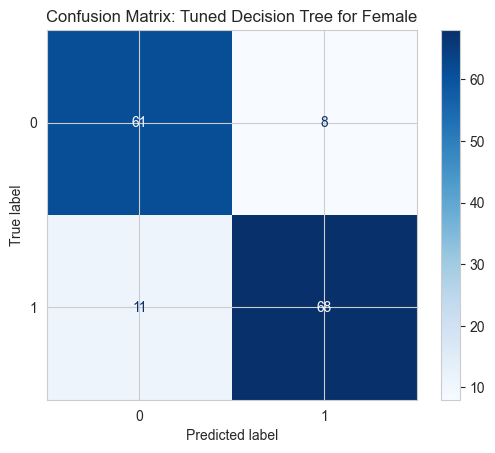

In [83]:
# Evaluate for Female using both default and tuned models
evaluate_decision_tree(female_data, "Female", default_model=default_tree, tuned_model=best_tree)

**Default vs. Tune Decision Tree for Female Subset**

The tuning process significantly improved the model's performance for the female subset. Accuracy increased in the tuned model (0.91 and 0.84). The MSE was improved as well (0.088 vs. 0.162), reflecting fewer misclassifications and a lower prediction error overall. Both classes showed improvements in precision, recall, and F1-scores. The tuned Decision Tree model more effectively distinguishes between cancer and non-cancer cases, making it the preferable choice for this subset.

In [84]:
# Define a function to train and evaluate the Random Forest model (default and tuned)
def evaluate_random_forest(data, gender_label, model):
    X = data.drop(columns=['Diagnosis', 'Gender'])  # Features
    y = data['Diagnosis']  # Target variable
    
    # Split the data into training and testing sets (80% training, 20% testing)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train the model on the subset
    model.fit(X_train, y_train)
    
    # Make predictions and evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)  # Calculate MSE
    class_report = classification_report(y_test, y_pred)
    
    # Display results
    print(f"{gender_label} Random Forest Accuracy:", accuracy)
    print(f"{gender_label} Random Forest MSE:", mse)
    print(f"{gender_label} Random Forest Classification Report:\n", class_report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap = "Blues")
    plt.title(f"Confusion Matrix: Random Forest for {gender_label}")
    plt.show()

Default Random Forest Results for Male:
Male Random Forest Accuracy: 0.934640522875817
Male Random Forest MSE: 0.06535947712418301
Male Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96       113
           1       0.97      0.78      0.86        40

    accuracy                           0.93       153
   macro avg       0.95      0.88      0.91       153
weighted avg       0.94      0.93      0.93       153


<Figure size 800x600 with 0 Axes>

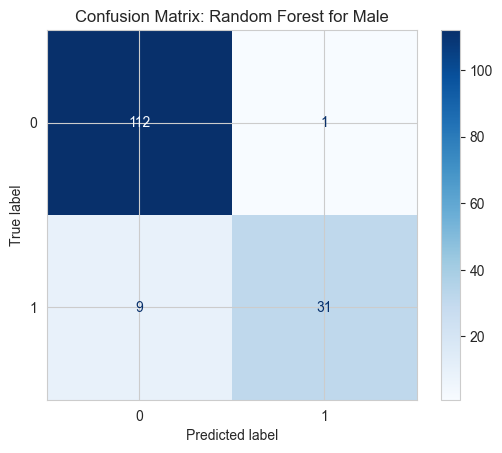

Tuned Random Forest Results for Male:
Male Random Forest Accuracy: 0.9281045751633987
Male Random Forest MSE: 0.0718954248366013
Male Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.98      0.95       113
           1       0.94      0.78      0.85        40

    accuracy                           0.93       153
   macro avg       0.93      0.88      0.90       153
weighted avg       0.93      0.93      0.93       153


<Figure size 800x600 with 0 Axes>

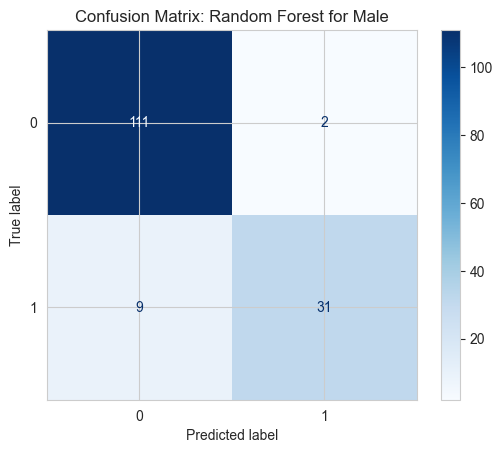

In [85]:

# Initialize the default Random Forest model
default_rf = RandomForestClassifier(random_state=42)

# Evaluate the default Random Forest model for Male
print("Default Random Forest Results for Male:")
evaluate_random_forest(male_data, "Male", model=default_rf)

# Evaluate the tuned Random Forest model for Male
print("Tuned Random Forest Results for Male:")
evaluate_random_forest(male_data, "Male", model=best_rf)

Default Random Forest Results for Female:
Female Random Forest Accuracy: 0.918918918918919
Female Random Forest MSE: 0.08108108108108109
Female Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91        69
           1       0.94      0.91      0.92        79

    accuracy                           0.92       148
   macro avg       0.92      0.92      0.92       148
weighted avg       0.92      0.92      0.92       148


<Figure size 800x600 with 0 Axes>

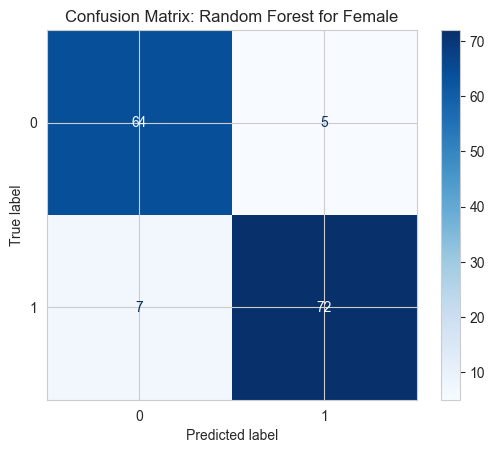

Tuned Random Forest Results for Female:
Female Random Forest Accuracy: 0.9054054054054054
Female Random Forest MSE: 0.0945945945945946
Female Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90        69
           1       0.92      0.90      0.91        79

    accuracy                           0.91       148
   macro avg       0.90      0.91      0.91       148
weighted avg       0.91      0.91      0.91       148


<Figure size 800x600 with 0 Axes>

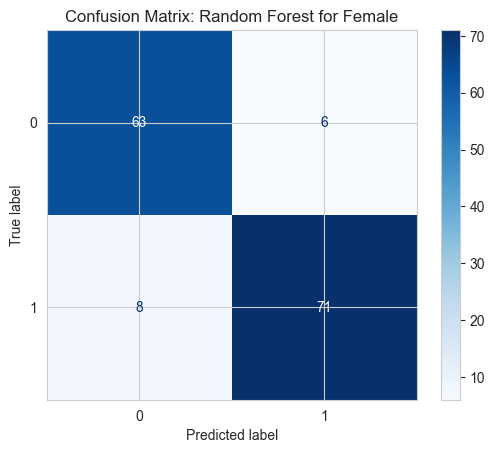

In [86]:

# Evaluate the default Random Forest model for Female
print("Default Random Forest Results for Female:")
evaluate_random_forest(female_data, "Female", model=default_rf)

# Evaluate the tuned Random Forest model for Female
print("Tuned Random Forest Results for Female:")
evaluate_random_forest(female_data, "Female", model=best_rf)

**Default vs Tune Random Forest Model**

The results for both the default and tuned Random Forest (RF) models demonstrate that hyperparameter tuning did not lead to any meaningful improvements in performance for either gender subset. This pattern is consistent with the findings from the generalized RF model, where the default model demonstrated strong performance without significant gains from tuning. The accuracy, precision, recall, F1-scores, and Mean Squared Error (MSE) remained relatively stable across default and tuned configurations, suggesting that the default RF model is already well-optimized for this dataset.

**Decision Tree vs Random Forest**

The default Random Forest model demonstrated robust performance for both the overall dataset and the gender-specific subsets, making it a reliable choice for predictive modeling. The model has high accuracies of 93.5% for males and 91.9% for females. Furthermore, the model maintained high precision and recall across both gender groups without significant loss in predictive power, which suggests it captures the underlying patterns effectively for both genders.

Based on our results, splitting the dataset by gender and applying a Random Forest model to each subset is a viable option. This approach allows the model to account for potential differences in feature importance or cancer risk factors between genders, enhancing interpretability and possibly improving diagnostic accuracy. However, the minimal performance gap between gender-specific and combined models suggests that splitting is not essential for maintaining accuracy.